# TP 3 | Manipulation d'images avec NumPy, Matplotlib et OpenCV

**Dataset :** [Food-101 Tiny](https://www.kaggle.com/datasets/msarmi9/food101tiny) | 10 classes de plats, 150 images d'entraînement et 50 de validation par classe.

### Objectifs
| # | Tâche |
|---|-------|
| 1 | Charger un petit dataset d'images |
| 2 | Afficher la dimension d'une image |
| 3 | Visualiser quelques images avec matplotlib |
| 4 | Normaliser les pixels dans l'intervalle [0, 1] |
| 5 | Calculer la moyenne et l'écart-type des pixels d'une image |
| 6 | Supprimer successivement les canaux R, V, B et analyser leur rôle |
| 7 | Tracer un rectangle autour d'un objet avec OpenCV |
| 8 | Dessiner manuellement une bounding box autour d'un objet choisi |

## 0. Configuration de l'environnement

Dépendances (gérées avec `uv`) : `kagglehub`, `numpy`, `matplotlib`, `opencv-python`.

```bash
uv add kagglehub numpy matplotlib opencv-python
```

In [1]:
from pathlib import Path
import random

import cv2
import kagglehub
import matplotlib.pyplot as plt
import numpy as np

# Reproductibilité des tirages aléatoires
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams["figure.dpi"] = 100
print(f"OpenCV {cv2.__version__} | NumPy {np.__version__}")

OpenCV 5.0.0 | NumPy 2.4.6


Fonctions utilitaires réutilisées dans tout le notebook.

> **Remarque :** OpenCV lit les images au format **BGR**, alors que matplotlib attend du **RGB**. On convertit donc systématiquement après `cv2.imread`.

In [ ]:
def load_image(path):
    """Charge une image depuis le disque et la renvoie en RGB (uint8)"""
    img_bgr = cv2.imread(str(path))
    if img_bgr is None:
        raise FileNotFoundError(f"Impossible de lire l'image : {path}")
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def show_images(images, titles=None, ncols=5, figsize_per_img=3):
    """Affiche une liste d'images dans une grille"""
    nrows = int(np.ceil(len(images) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * figsize_per_img, nrows * figsize_per_img))
    axes = np.atleast_1d(axes).ravel()
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < len(images):
            ax.imshow(images[i])
            if titles is not None:
                ax.set_title(titles[i], fontsize=10)
    plt.tight_layout()
    plt.show()

---
## 1. Charger un petit dataset d'images

On télécharge le dataset via `kagglehub` (mis en cache dans `~/.cache/kagglehub` après le premier téléchargement).

In [3]:
path = kagglehub.dataset_download("msarmi9/food101tiny")
DATA_DIR = Path(path) / "data" / "food-101-tiny"
TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"

print("Dossier du dataset :", DATA_DIR)

Dossier du dataset : C:\Users\DELL\.cache\kagglehub\datasets\msarmi9\food101tiny\versions\1\data\food-101-tiny


### 1.1 Exploration de la structure

In [4]:
classes = sorted(d.name for d in TRAIN_DIR.iterdir() if d.is_dir())
print(f"{len(classes)} classes : {classes}\n")

print(f"{'Classe':<15}{'train':>8}{'valid':>8}")
print("-" * 31)
for c in classes:
    n_train = len(list((TRAIN_DIR / c).glob("*.jpg")))
    n_valid = len(list((VALID_DIR / c).glob("*.jpg")))
    print(f"{c:<15}{n_train:>8}{n_valid:>8}")

10 classes : ['apple_pie', 'bibimbap', 'cannoli', 'edamame', 'falafel', 'french_toast', 'ice_cream', 'ramen', 'sushi', 'tiramisu']

Classe            train   valid
-------------------------------
apple_pie           150      50
bibimbap            150      50
cannoli             150      50
edamame             150      50
falafel             150      50
french_toast        150      50
ice_cream           150      50
ramen               150      50
sushi               150      50
tiramisu            150      50


### 1.2 Chargement d'un sous-ensemble en mémoire

Pour rester léger, on charge **5 images par classe** (50 images au total) depuis le jeu d'entraînement.

In [5]:
N_PER_CLASS = 5

images, labels, paths = [], [], []
for c in classes:
    files = sorted((TRAIN_DIR / c).glob("*.jpg"))
    for f in random.sample(files, N_PER_CLASS):
        images.append(load_image(f))
        labels.append(c)
        paths.append(f)

print(f"{len(images)} images chargées ({N_PER_CLASS} par classe)")

50 images chargées (5 par classe)


---
## 2. Afficher la dimension d'une image

Une image couleur est un tableau NumPy de forme **(hauteur, largeur, canaux)**.

In [6]:
img = images[0]

h, w, c = img.shape
print(f"Image       : {paths[0].name} (classe : {labels[0]})")
print(f"Shape       : {img.shape}  ->  hauteur={h}, largeur={w}, canaux={c}")
print(f"Nb pixels   : {h * w:,}")
print(f"Nb valeurs  : {img.size:,}")
print(f"Type        : {img.dtype}")
print(f"Min / Max   : {img.min()} / {img.max()}")

Image       : 1159801.jpg (classe : apple_pie)
Shape       : (512, 512, 3)  ->  hauteur=512, largeur=512, canaux=3
Nb pixels   : 262,144
Nb valeurs  : 786,432
Type        : uint8
Min / Max   : 0 / 255


Les images de Food-101 n'ont **pas toutes la même taille** (le plus grand côté vaut 512 px). Vérifions sur notre sous-ensemble :

In [7]:
shapes = [im.shape for im in images]
unique_shapes = sorted(set(shapes), key=shapes.count, reverse=True)

print(f"{len(unique_shapes)} dimensions différentes :")
for s in unique_shapes:
    print(f"  {s} : {shapes.count(s)} image(s)")

11 dimensions différentes :
  (512, 512, 3) : 28 image(s)
  (384, 512, 3) : 8 image(s)
  (512, 384, 3) : 4 image(s)
  (382, 512, 3) : 2 image(s)
  (341, 512, 3) : 2 image(s)
  (511, 512, 3) : 1 image(s)
  (340, 512, 3) : 1 image(s)
  (512, 341, 3) : 1 image(s)
  (512, 508, 3) : 1 image(s)
  (512, 306, 3) : 1 image(s)
  (512, 511, 3) : 1 image(s)


> En pratique, avant d'entraîner un modèle, on redimensionne toutes les images à une taille commune (ex. `cv2.resize(img, (224, 224))`).

---
## 3. Visualiser quelques images avec matplotlib

Une image par classe :

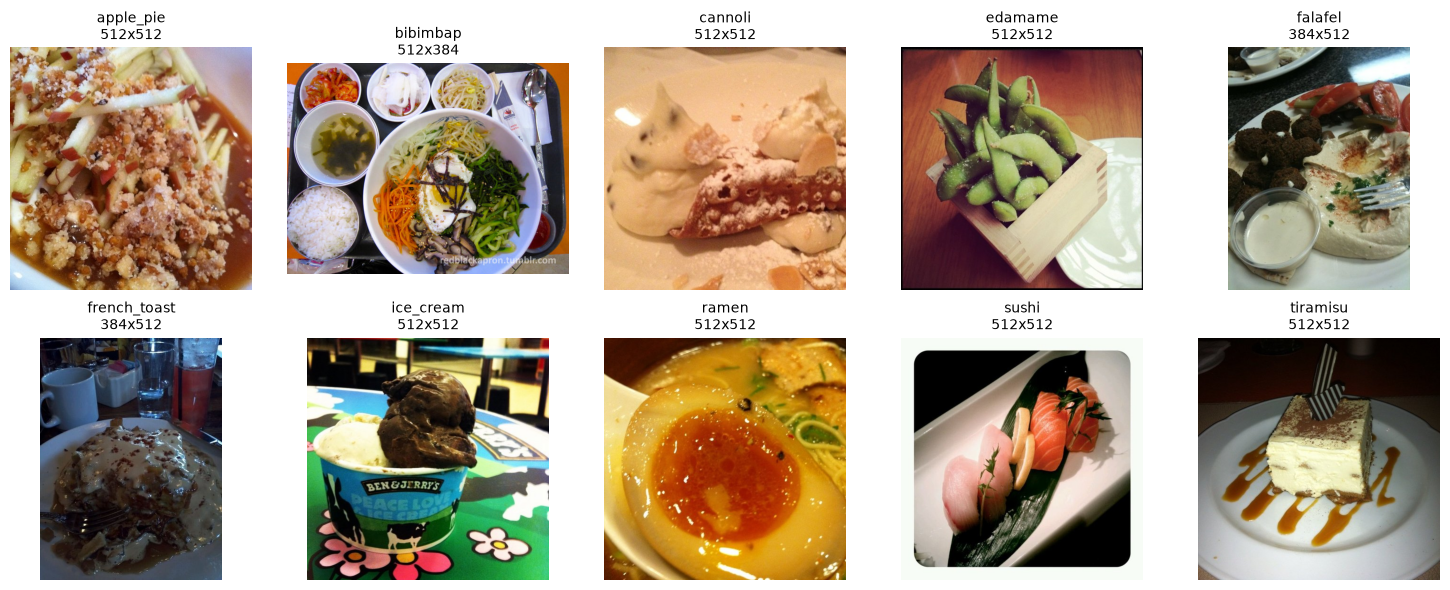

In [8]:
idx_per_class = [labels.index(c) for c in classes]
show_images(
    [images[i] for i in idx_per_class],
    titles=[f"{labels[i]}\n{images[i].shape[1]}x{images[i].shape[0]}" for i in idx_per_class],
)

Toutes les images d'une même classe (ex. `sushi`) :

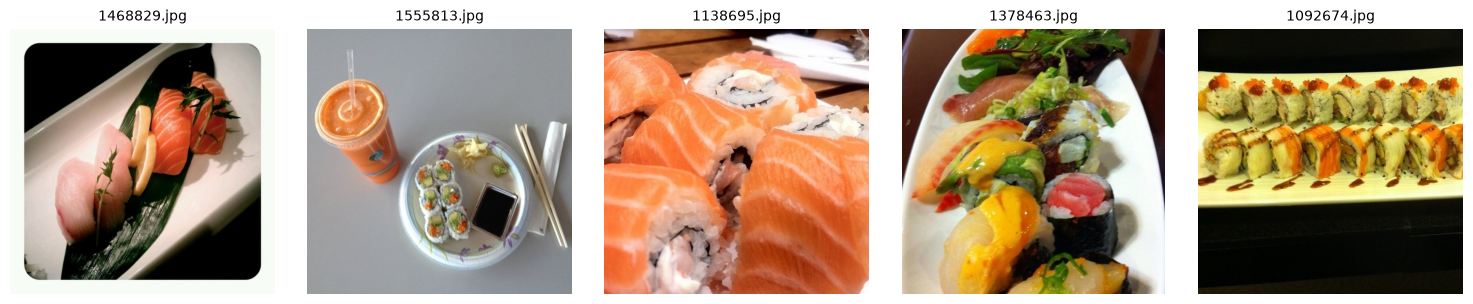

In [9]:
sushi_idx = [i for i, l in enumerate(labels) if l == "sushi"]
show_images([images[i] for i in sushi_idx], titles=[paths[i].name for i in sushi_idx])

---
## 4. Normaliser les pixels (0 – 1)

Les pixels sont stockés en `uint8` (entiers de 0 à 255). On les ramène dans **[0, 1]** en divisant par 255 :

$$x_{norm} = \frac{x}{255}$$

Intérêt : des valeurs petites et homogènes stabilisent l'apprentissage des réseaux de neurones (gradients mieux conditionnés).

In [10]:
img_norm = img.astype(np.float32) / 255.0

print(f"{'':<12}{'dtype':<10}{'min':>8}{'max':>8}")
print(f"{'Avant':<12}{str(img.dtype):<10}{img.min():>8}{img.max():>8}")
print(f"{'Après':<12}{str(img_norm.dtype):<10}{img_norm.min():>8.3f}{img_norm.max():>8.3f}")

            dtype          min     max
Avant       uint8            0     255
Après       float32      0.000   1.000


Normalisation de tout le sous-ensemble et comparaison des histogrammes :

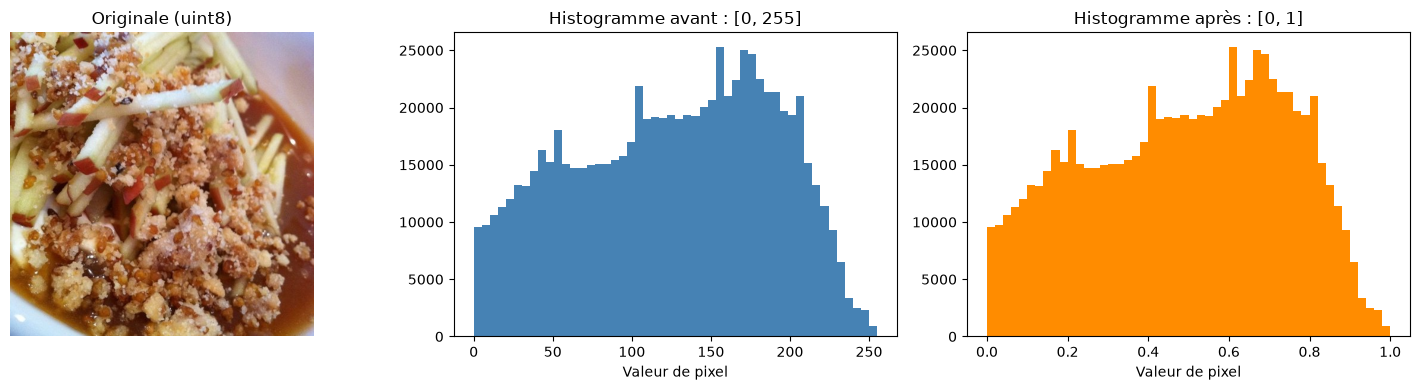

In [11]:
images_norm = [im.astype(np.float32) / 255.0 for im in images]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(img)
axes[0].set_title("Originale (uint8)")
axes[0].axis("off")

axes[1].hist(img.ravel(), bins=50, color="steelblue")
axes[1].set_title("Histogramme avant : [0, 255]")
axes[1].set_xlabel("Valeur de pixel")

axes[2].hist(img_norm.ravel(), bins=50, color="darkorange")
axes[2].set_title("Histogramme après : [0, 1]")
axes[2].set_xlabel("Valeur de pixel")

plt.tight_layout()
plt.show()

> La forme de la distribution est **identique** : seule l'échelle change. L'image s'affiche de la même façon car `imshow` interprète les `float` comme des valeurs dans [0, 1].

---
## 5. Moyenne et écart-type des pixels d'une image

$$\mu = \frac{1}{N}\sum_{i=1}^{N} x_i \qquad \sigma = \sqrt{\frac{1}{N}\sum_{i=1}^{N} (x_i - \mu)^2}$$

- **Moyenne** → luminosité globale de l'image.
- **Écart-type** → contraste (dispersion des intensités).

### 5.1 Statistiques globales (tous canaux confondus)

In [12]:
mean = img_norm.mean()
std = img_norm.std()

# Vérification avec les formules explicites
mean_manual = img_norm.sum() / img_norm.size
std_manual = np.sqrt(((img_norm - mean_manual) ** 2).sum() / img_norm.size)

print(f"Moyenne    : {mean:.4f}   (manuel : {mean_manual:.4f})")
print(f"Écart-type : {std:.4f}   (manuel : {std_manual:.4f})")

Moyenne    : 0.4926   (manuel : 0.4926)
Écart-type : 0.2456   (manuel : 0.2456)


### 5.2 Statistiques par canal (R, V, B)

Rouge  : moyenne = 0.6411 | écart-type = 0.1645
Vert   : moyenne = 0.4792 | écart-type = 0.2243
Bleu   : moyenne = 0.3576 | écart-type = 0.2509


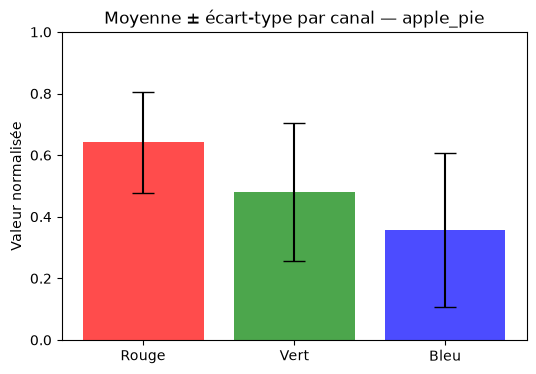

In [13]:
channel_names = ["Rouge", "Vert", "Bleu"]
channel_colors = ["red", "green", "blue"]

means_c = img_norm.mean(axis=(0, 1))  # moyenne sur hauteur et largeur
stds_c = img_norm.std(axis=(0, 1))

for name, m, s in zip(channel_names, means_c, stds_c):
    print(f"{name:<6} : moyenne = {m:.4f} | écart-type = {s:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(channel_names, means_c, yerr=stds_c, color=channel_colors, alpha=0.7, capsize=8)
ax.set_ylim(0, 1)
ax.set_ylabel("Valeur normalisée")
ax.set_title(f"Moyenne ± écart-type par canal — {labels[0]}")
plt.show()

### 5.3 Statistiques sur le sous-ensemble

Les moyennes/écarts-types par canal calculés sur un dataset servent à la **standardisation** : $x' = (x - \mu) / \sigma$.

In [14]:
all_pixels = np.concatenate([im.reshape(-1, 3) for im in images_norm], axis=0)
ds_mean = all_pixels.mean(axis=0)
ds_std = all_pixels.std(axis=0)

print(f"Moyenne par canal (R, V, B)    : {np.round(ds_mean, 4)}")
print(f"Écart-type par canal (R, V, B) : {np.round(ds_std, 4)}")

Moyenne par canal (R, V, B)    : [0.509  0.4234 0.3119]
Écart-type par canal (R, V, B) : [0.2866 0.2768 0.269 ]


---
## 6. Suppression successive des canaux Rouge, Vert et Bleu

Supprimer un canal = mettre toutes ses valeurs à **0**. On travaille sur des **copies** pour ne pas modifier l'image originale.

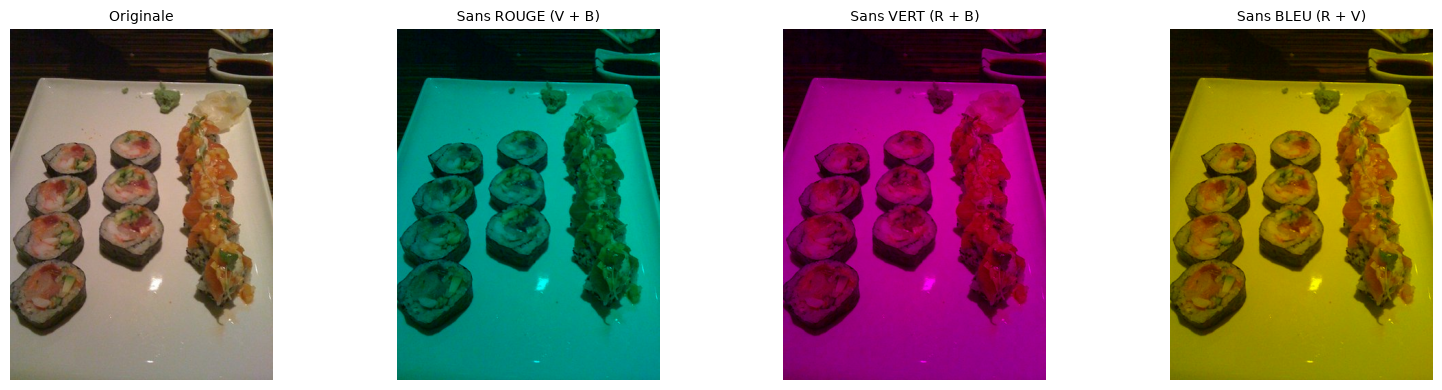

In [15]:
# Image colorée et variée pour bien voir l'effet de chaque canal
demo = load_image(TRAIN_DIR / "sushi" / "100332.jpg")

def remove_channel(image, channel):
    out = image.copy()
    out[:, :, channel] = 0
    return out

no_red = remove_channel(demo, 0)
no_green = remove_channel(demo, 1)
no_blue = remove_channel(demo, 2)

show_images(
    [demo, no_red, no_green, no_blue],
    titles=["Originale", "Sans ROUGE (V + B)", "Sans VERT (R + B)", "Sans BLEU (R + V)"],
    ncols=4, figsize_per_img=4,
)

Pour mieux comprendre, visualisons chaque canal **isolé** (en niveaux de gris : blanc = forte intensité) :

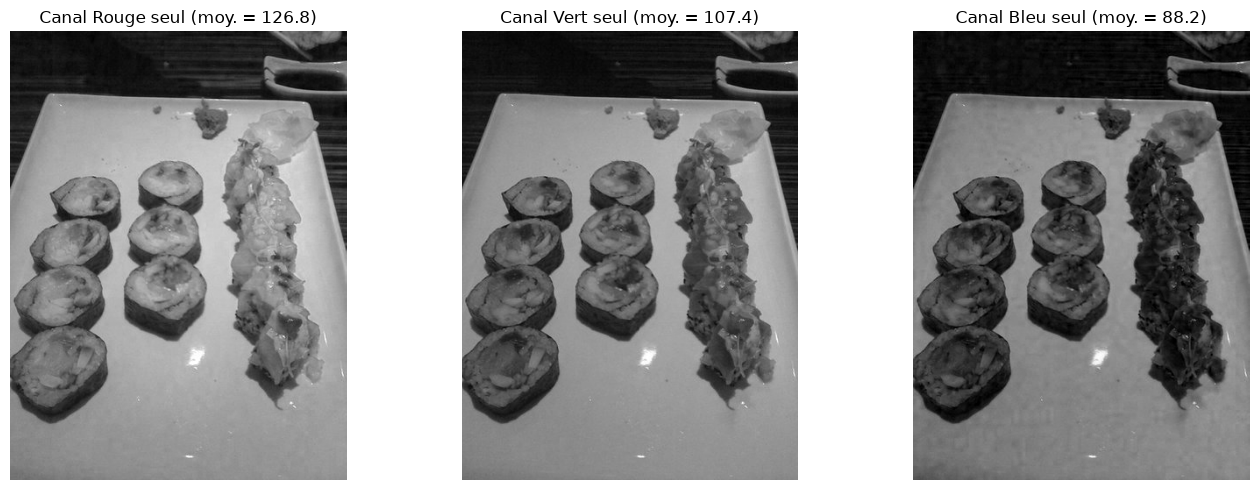

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, (ax, name) in enumerate(zip(axes, channel_names)):
    ax.imshow(demo[:, :, i], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Canal {name} seul (moy. = {demo[:, :, i].mean():.1f})")
    ax.axis("off")
plt.tight_layout()
plt.show()

### Quel est le rôle de chaque canal dans la représentation de l'image ?

Une image couleur repose sur la **synthèse additive** : chaque pixel est la somme de trois intensités lumineuses **Rouge**, **Vert** et **Bleu**. Toutes les couleurs visibles sont obtenues en les combinant (R+V = jaune, R+B = magenta, V+B = cyan, R+V+B = blanc).

| Canal supprimé | Résultat visuel | Interprétation |
|---|---|---|
| **Rouge** | Image dominée par le **cyan** (V+B) ; le saumon et la sauce virent au gris-vert/bleu, les zones chaudes s'assombrissent | Le rouge porte les **tons chauds** : chair, saumon, orange, bois, peau |
| **Vert** | Image dominée par le **magenta** (R+B) ; l'avocat et le wasabi deviennent sombres ; l'image paraît nettement **plus sombre** | Le vert porte l'essentiel de la **luminosité** et des **détails** : l'œil humain y est le plus sensible (≈ 59 % dans la luminance `Y = 0.299R + 0.587G + 0.114B`) |
| **Bleu** | Image dominée par le **jaune** (R+V) ; les blancs (assiette, riz) deviennent jaunes | Le bleu porte les **tons froids** et l'équilibre des blancs ; il contribue peu à la luminosité (≈ 11 %) |

**En résumé :**
- Chaque canal encode la quantité d'une couleur primaire en chaque pixel — c'est une carte d'intensité en niveaux de gris.
- Aucun canal n'est suffisant seul : c'est leur **combinaison** qui reconstruit la couleur réelle.
- Le **vert** est le canal le plus informatif pour la structure/luminosité, le **rouge** et le **bleu** apportent surtout la teinte (chaud / froid).

---
## 7. Tracer un rectangle autour d'un objet avec OpenCV

Signature :
```python
cv2.rectangle(image, pt1=(x_min, y_min), pt2=(x_max, y_max), color, thickness)
```

> **Attention :** les coordonnées OpenCV sont au format **(x, y) = (colonne, ligne)**, alors que l'indexation NumPy est `img[ligne, colonne]`. L'origine (0, 0) est le coin **en haut à gauche**.

On encadre la **verrine de tiramisu**.

Shape : (384, 512, 3)


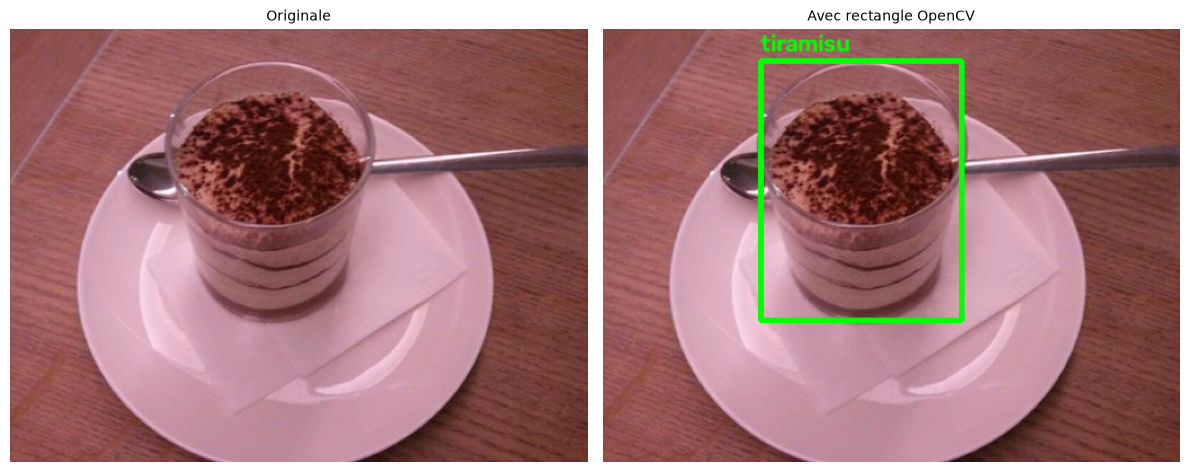

In [17]:
tiramisu = load_image(TRAIN_DIR / "tiramisu" / "1002946.jpg")
print("Shape :", tiramisu.shape)

# Coordonnées de la verrine (x_min, y_min) -> (x_max, y_max)
pt1, pt2 = (140, 28), (318, 258)

annotated = tiramisu.copy()  # cv2.rectangle modifie l'image en place
cv2.rectangle(annotated, pt1, pt2, color=(0, 255, 0), thickness=3)  # vert en RGB
cv2.putText(annotated, "tiramisu", (pt1[0], pt1[1] - 8),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2, cv2.LINE_AA)

show_images([tiramisu, annotated], titles=["Originale", "Avec rectangle OpenCV"], ncols=2, figsize_per_img=6)

---
## 8. Bounding box manuelle autour d'un objet choisi

**Objet choisi :** le maki en haut à gauche de l'assiette de sushis.

**Démarche :**
1. Afficher l'image avec une **grille graduée** pour lire les coordonnées des pixels.
2. Relever visuellement les bords de l'objet : `x_min`, `y_min`, `x_max`, `y_max`.
3. Dessiner la box, puis **vérifier** en recadrant la zone.

### 8.1 Repérage des coordonnées avec une grille

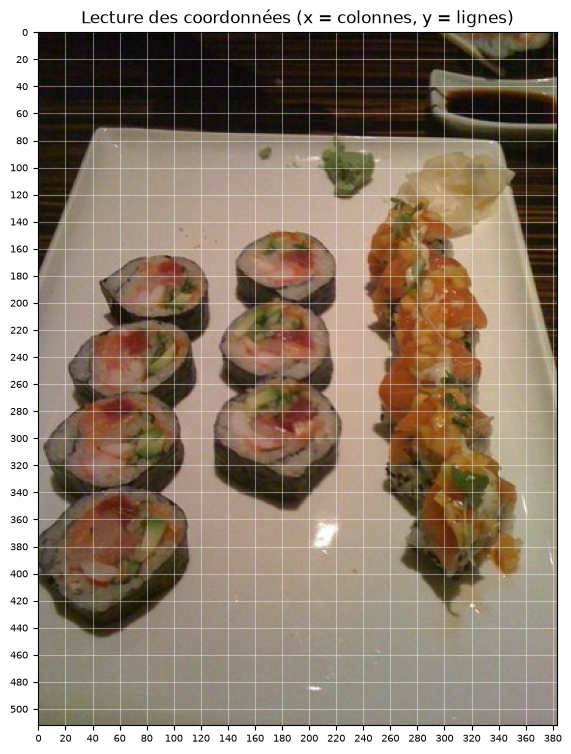

In [18]:
sushi = load_image(TRAIN_DIR / "sushi" / "100332.jpg")
H, W = sushi.shape[:2]

fig, ax = plt.subplots(figsize=(7, 9))
ax.imshow(sushi)
ax.set_xticks(range(0, W, 20))
ax.set_yticks(range(0, H, 20))
ax.tick_params(labelsize=7)
ax.grid(True, color="white", alpha=0.4)
ax.set_title("Lecture des coordonnées (x = colonnes, y = lignes)")
plt.show()

### 8.2 Tracé de la bounding box

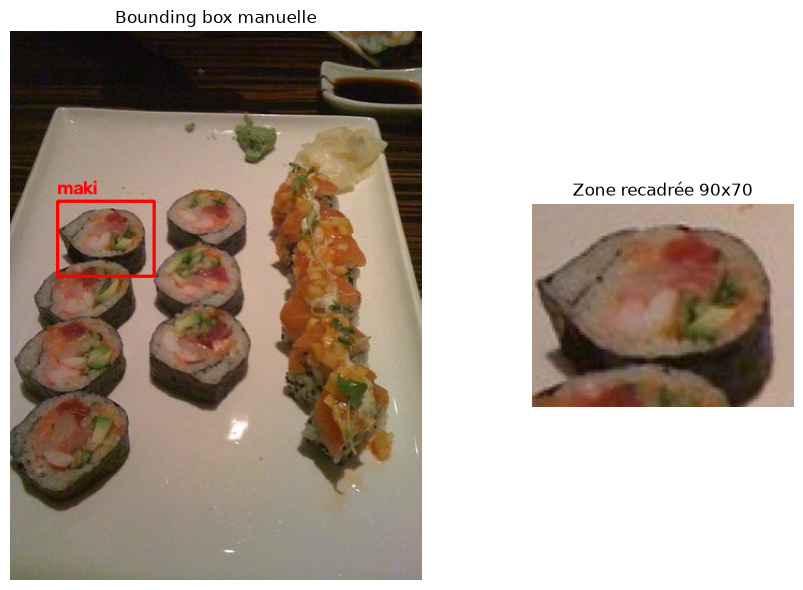

In [19]:
# Coordonnées relevées manuellement sur la grille ci-dessus
x_min, y_min = 44, 158
x_max, y_max = 134, 228
label = "maki"

boxed = sushi.copy()
cv2.rectangle(boxed, (x_min, y_min), (x_max, y_max), color=(255, 0, 0), thickness=2)
cv2.putText(boxed, label, (x_min, y_min - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2, cv2.LINE_AA)

# Vérification : la zone recadrée doit contenir uniquement l'objet
crop = sushi[y_min:y_max, x_min:x_max]  # NumPy : [lignes, colonnes]

fig, axes = plt.subplots(1, 2, figsize=(10, 6), gridspec_kw={"width_ratios": [3, 1]})
axes[0].imshow(boxed)
axes[0].set_title("Bounding box manuelle")
axes[0].axis("off")
axes[1].imshow(crop)
axes[1].set_title(f"Zone recadrée {crop.shape[1]}x{crop.shape[0]}")
axes[1].axis("off")
plt.tight_layout()
plt.show()

### 8.3 Formats d'annotation courants

Une même box peut s'exprimer dans plusieurs formats selon l'outil / le modèle utilisé :

In [20]:
bw, bh = x_max - x_min, y_max - y_min
xc, yc = x_min + bw / 2, y_min + bh / 2

print(f"Pascal VOC (x_min, y_min, x_max, y_max) : ({x_min}, {y_min}, {x_max}, {y_max})")
print(f"COCO       (x_min, y_min, largeur, hauteur) : ({x_min}, {y_min}, {bw}, {bh})")
print(f"YOLO       (x_c, y_c, l, h) normalisés  : ({xc / W:.4f}, {yc / H:.4f}, {bw / W:.4f}, {bh / H:.4f})")

Pascal VOC (x_min, y_min, x_max, y_max) : (44, 158, 134, 228)
COCO       (x_min, y_min, largeur, hauteur) : (44, 158, 90, 70)
YOLO       (x_c, y_c, l, h) normalisés  : (0.2318, 0.3770, 0.2344, 0.1367)


---
## Conclusion

| Notion | À retenir |
|---|---|
| Représentation | Une image couleur = tableau NumPy `(H, W, 3)` en `uint8` |
| Chargement | `cv2.imread` renvoie du **BGR** → convertir en RGB pour matplotlib |
| Normalisation | `img / 255.0` → valeurs dans [0, 1], en `float32` |
| Statistiques | Moyenne ≈ luminosité, écart-type ≈ contraste ; calculables par canal avec `axis=(0, 1)` |
| Canaux | Synthèse additive R + V + B ; le vert porte l'essentiel de la luminosité |
| Annotation | `cv2.rectangle` utilise des coordonnées `(x, y)` ; NumPy indexe `[y, x]` |
| Bounding box | Formats VOC, COCO, YOLO selon l'outil de détection |